# Root Locus

The root locus method is a tool to study the evolution of the poles of the closed loop system, to determine the proportional feedback to stabilize a plant.

In [1]:
using Plots

## 1. Proportional Feedback

We take the example (10.27) from the textbook and set up the transfer function of the closed loop for a simple proportional feedback.

In [2]:
using SymPy

In [3]:
s = Sym("s")

s

In [4]:
a = s^2 + 7*s + 4

 2          
s  + 7*s + 4

In [5]:
b = s^3 - 3*s^2 + 2*s + 5

 3      2          
s  - 3*s  + 2*s + 5

In [6]:
P = a/b

     2             
    s  + 7*s + 4   
-------------------
 3      2          
s  - 3*s  + 2*s + 5

In [7]:
kappa = Sym("kappa")

kappa

The transfer function of the closed loop system is Q:

In [8]:
Q = P/(1 + kappa*P)

                   2                            
                  s  + 7*s + 4                  
------------------------------------------------
/      / 2          \    \                      
|kappa*\s  + 7*s + 4/    | / 3      2          \
|-------------------- + 1|*\s  - 3*s  + 2*s + 5/
| 3      2               |                      
\s  - 3*s  + 2*s + 5     /                      

We are interested in the denominator.  Let us look at the arguments of Q.

In [9]:
Q.args

(1/(kappa*(s^2 + 7*s + 4)/(s^3 - 3*s^2 + 2*s + 5) + 1), 1/(s^3 - 3*s^2 + 2*s + 5), s^2 + 7*s + 4)

The denominator is the product of the first two arguments.

In [10]:
println(Q.args[1])
println(Q.args[2])

1/(kappa*(s^2 + 7*s + 4)/(s^3 - 3*s^2 + 2*s + 5) + 1)
1/(s^3 - 3*s^2 + 2*s + 5)


In [11]:
nQ = Q.args[1]*Q.args[2]

                       1                        
------------------------------------------------
/      / 2          \    \                      
|kappa*\s  + 7*s + 4/    | / 3      2          \
|-------------------- + 1|*\s  - 3*s  + 2*s + 5/
| 3      2               |                      
\s  - 3*s  + 2*s + 5     /                      

In [12]:
pQ = 1/nQ

/      / 2          \    \                      
|kappa*\s  + 7*s + 4/    | / 3      2          \
|-------------------- + 1|*\s  - 3*s  + 2*s + 5/
| 3      2               |                      
\s  - 3*s  + 2*s + 5     /                      

In [13]:
sQ = simplify(pQ)

      / 2          \    3      2          
kappa*\s  + 7*s + 4/ + s  - 3*s  + 2*s + 5

We are interested in the roots of ``sQ`` for increasing values of ``kappa``.

## 2. Moving Poles

We compute the poles numerically, after substituting a value for kappa.

In [14]:
eQ = expand(sQ)

       2                          3      2          
kappa*s  + 7*kappa*s + 4*kappa + s  - 3*s  + 2*s + 5

In [15]:
degree(eQ,s)

3

In [16]:
cffs = [eQ.coeff(s,k) for k=0:3]

4-element Vector{Sym{PyCall.PyObject}}:
 4*kappa + 5
 7*kappa + 2
   kappa - 3
           1

In [17]:
c1 = [c.subs(Dict(kappa=>1)) for c in cffs]

4-element Vector{Sym{PyCall.PyObject}}:
  9
  9
 -2
  1

In [18]:
cf1 = [Float64(c1[k]) for k=1:size(c1,1)]

4-element Vector{Float64}:
  9.0
  9.0
 -2.0
  1.0

In [19]:
p1s = sum([cf1[k]*s^(k-1) for k=1:size(cf1,1)])

     3        2              
1.0*s  - 2.0*s  + 9.0*s + 9.0

In [20]:
r1 = SymPy.roots(p1s)

Dict{Sym{PyCall.PyObject}, Sym{PyCall.PyObject}} with 3 entries:
  1.40028323611539 - 3.04651382395942*I => 1
  -0.800566472230790                    => 1
  1.40028323611539 + 3.04651382395942*I => 1

In [21]:
v1 = [Float64(real(r[1])) + Float64(imag(r[1]))*Complex(0,1) for r in r1]

3-element Vector{ComplexF64}:
 1.400283236115395 - 3.046513823959417im
 -0.80056647223079 + 0.0im
 1.400283236115395 + 3.046513823959417im

In [22]:
"""
    function tripletsort!(v)

sorts the three complex numbers in v in
the order of real parts.
"""
function tripletsort!(v)
    if real(v[1]) > real(v[2])
        (v[1], v[2]) = (v[2], v[1])
    end
    if real(v[1]) > real(v[3])
        (v[1], v[3]) = (v[3], v[1])
    end
    if real(v[2]) > real(v[3])
        (v[2], v[3]) = (v[3], v[2])
    end
    if real(v[1]) == real(v[2])
        if imag(v[1]) > imag(v[2])
            (v[1], v[2]) = (v[2], v[1])
        end
    end
    if real(v[1]) == real(v[3])
        if imag(v[1]) > imag(v[3])
            (v[1], v[3]) = (v[3], v[1])
        end
    end
    if real(v[2]) == real(v[3])
        if imag(v[2]) > imag(v[3])
            (v[2], v[3]) = (v[3], v[2])
        end
    end
end  

tripletsort!

In [23]:
tripletsort!(v1)
v1

3-element Vector{ComplexF64}:
 -0.80056647223079 + 0.0im
 1.400283236115395 - 3.046513823959417im
 1.400283236115395 + 3.046513823959417im

Now we are ready to define a function which returns the roots for a value of kappa.

In [24]:
"""
    function locus(kp::Float64, p)

returns the roots of the polynomial p in s defined by
the coefficients where kappa is replaced by kp.
"""
function locus(kp::Float64, p)
    cffs = [p.coeff(s,k) for k=0:3]
    c1 = [c.subs(Dict(kappa=>kp)) for c in cffs]
    cf1 = [Float64(c1[k]) for k=1:size(c1,1)]
    p1s = sum([cf1[k]*s^(k-1) for k=1:size(cf1,1)])
    r1 = roots(p1s)
    v1 = [Float64(real(r[1])) + Float64(imag(r[1]))*Complex(0,1) for r in r1]
    tripletsort!(v1)
    return v1
end

locus

In [25]:
locus(1.0, eQ)

3-element Vector{ComplexF64}:
 -0.80056647223079 + 0.0im
 1.400283236115395 - 3.046513823959417im
 1.400283236115395 + 3.046513823959417im

In [26]:
locus(2.0, eQ)

3-element Vector{ComplexF64}:
 -0.7508142199275265 + 0.0im
  0.8754071099637633 - 4.0679477140934095im
  0.8754071099637633 + 4.0679477140934095im

In [27]:
pole1(t) = locus(t, eQ)[1]
pole2(t) = locus(t, eQ)[2]
pole3(t) = locus(t, eQ)[3]

pole3 (generic function with 1 method)

In [28]:
pole1(2.0)

-0.7508142199275265 + 0.0im

In [29]:
range = 0:0.01:2
poles1 = [pole1(t) for t in range]
path1re = [real(p) for p in poles1]
path1im = [imag(p) for p in poles1];

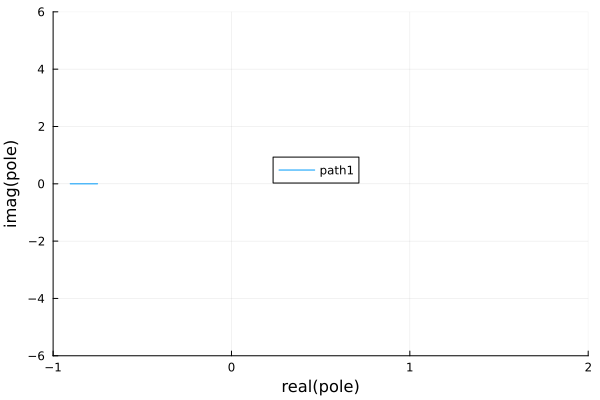

In [30]:
plot(path1re, path1im, xlabel="real(pole)", ylabel="imag(pole)", label="path1",
     legend=(0.5, 0.54), xlims=[-1.0, 2.0], ylims=[-6.0, 6.0])

In [31]:
poles2 = [pole2(t) for t in range]
path2re = [real(p) for p in poles2]
path2im = [imag(p) for p in poles2]
poles3 = [pole3(t) for t in range]
path3re = [real(p) for p in poles3]
path3im = [imag(p) for p in poles3];

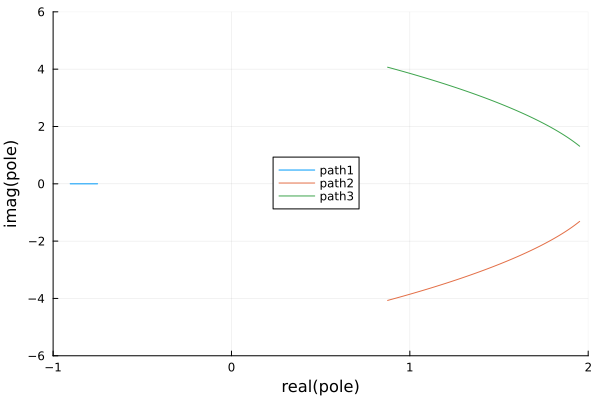

In [32]:
plot!(path2re, path2im, label="path2")
plot!(path3re, path3im, label="path3")

In [33]:
# savefig("figrootlocuskappa2.png")

In [34]:
range = 0:0.01:3
poles1 = [pole1(t) for t in range]
path1re = [real(p) for p in poles1]
path1im = [imag(p) for p in poles1];
poles2 = [pole2(t) for t in range]
path2re = [real(p) for p in poles2]
path2im = [imag(p) for p in poles2]
poles3 = [pole3(t) for t in range]
path3re = [real(p) for p in poles3]
path3im = [imag(p) for p in poles3];

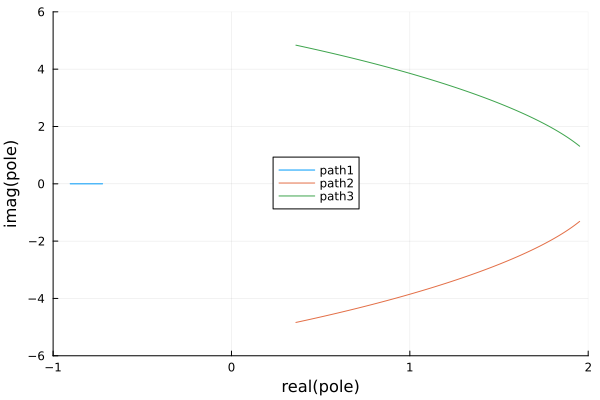

In [35]:
plot(path1re, path1im, label="path1", xlabel="real(pole)", ylabel="imag(pole)",
     legend=(0.5, 0.54), xlims=[-1.0, 2.0], ylims=[-6.0, 6.0])
plot!(path2re, path2im, label="path2")
plot!(path3re, path3im, label="path3")

In [36]:
# savefig("figrootlocuskappa3.png")

In [37]:
range = 0:0.01:5
poles1 = [pole1(t) for t in range]
path1re = [real(p) for p in poles1]
path1im = [imag(p) for p in poles1];
poles2 = [pole2(t) for t in range]
path2re = [real(p) for p in poles2]
path2im = [imag(p) for p in poles2]
poles3 = [pole3(t) for t in range]
path3re = [real(p) for p in poles3]
path3im = [imag(p) for p in poles3];

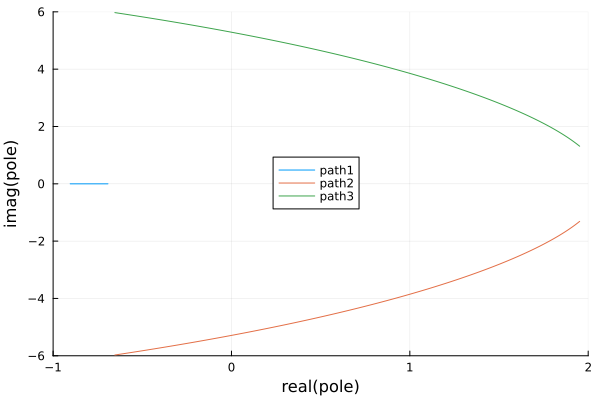

In [38]:
plot(path1re, path1im, label="path1", xlabel="real(pole)", ylabel="imag(pole)",
     legend=(0.5, 0.54), xlims=[-1.0, 2.0], ylims=[-6.0, 6.0])
plot!(path2re, path2im, label="path2")
plot!(path3re, path3im, label="path3")

In [39]:
# savefig("figrootlocuskappa5.png")